In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam


In [2]:
df =pd.read_csv(r"C:\Users\mucha\OneDrive\Desktop\Infosys internship\Processed\hourly_device_energy.csv")

In [3]:
scaler = MinMaxScaler(feature_range=(0, 1))
energy_scaled = scaler.fit_transform(df[['Energy Consumption (kWh)']])

In [4]:
def create_sequences(data, time_steps=24):
    X, y = [], []
    for i in range(time_steps, len(data)):
        X.append(data[i-time_steps:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

In [5]:
TIME_STEPS = 24
X, y = create_sequences(energy_scaled, TIME_STEPS)

split_index = int(0.8 * len(X))
X_train, X_test = X[:split_index], X[split_index:]
y_train, y_test = y[:split_index], y[split_index:]


In [6]:
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

In [7]:
model = Sequential()
model.add(LSTM(64, return_sequences=True, input_shape=(TIME_STEPS, 1)))
model.add(Dropout(0.2))
model.add(LSTM(32))
model.add(Dropout(0.2))
model.add(Dense(1))

C:\Users\mucha\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [14]:
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mean_squared_error'
)

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(
    X_train,
    y_train, 
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/20
1976/1976 ━━━━━━━━━━━━━━━━━━━━ 131s 60ms/step - loss: 0.0059 - val_loss: 0.0020
Epoch 2/20
1976/1976 ━━━━━━━━━━━━━━━━━━━━ 121s 61ms/step - loss: 0.0059 - val_loss: 0.0020
Epoch 3/20
1976/1976 ━━━━━━━━━━━━━━━━━━━━ 121s 61ms/step - loss: 0.0059 - val_loss: 0.0020
Epoch 4/20
1976/1976 ━━━━━━━━━━━━━━━━━━━━ 112s 57ms/step - loss: 0.0059 - val_loss: 0.0020
Epoch 5/20
1976/1976 ━━━━━━━━━━━━━━━━━━━━ 113s 57ms/step - loss: 0.0059 - val_loss: 0.0020
Epoch 6/20
1976/1976 ━━━━━━━━━━━━━━━━━━━━ 111s 56ms/step - loss: 0.0059 - val_loss: 0.0020
Epoch 7/20
1976/1976 ━━━━━━━━━━━━━━━━━━━━ 112s 57ms/step - loss: 0.0059 - val_loss: 0.0020
Epoch 8/20
1976/1976 ━━━━━━━━━━━━━━━━━━━━ 109s 55ms/step - loss: 0.0059 - val_loss: 0.0020
Epoch 9/20
1976/1976 ━━━━━━━━━━━━━━━━━━━━ 110s 55ms/step - loss: 0.0059 - val_loss: 0.0020
Epoch 10/20
1976/1976 ━━━━━━━━━━━━━━━━━━━━ 111s 56ms/step - loss: 0.0059 - val_loss: 0.0020
Epoch 11/20
1976/1976 ━━━━━━━━━━━━━━━━━━━━ 115s 58ms/step - loss: 0.0059 - val_loss: 0.00

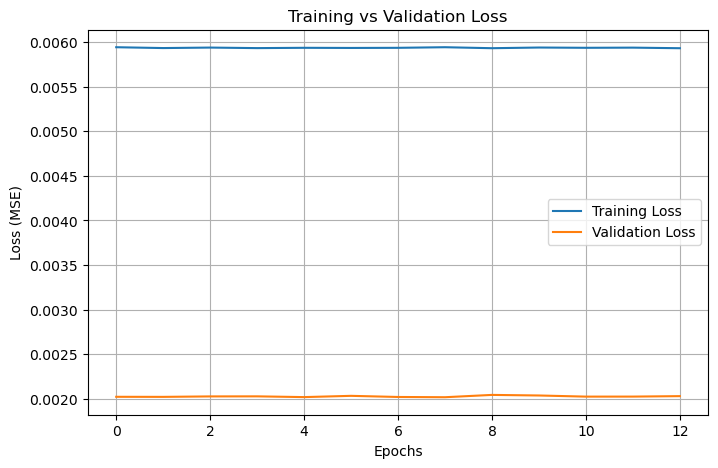

In [15]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid(True)
plt.show()


In [17]:
y_pred_scaled = model.predict(X_test)

y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))
y_pred_actual = scaler.inverse_transform(y_pred_scaled)

mae = mean_absolute_error(y_test_actual, y_pred_actual)
rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual))

print("LSTM MAE:", mae)
print("LSTM RMSE:", rmse)


549/549 ━━━━━━━━━━━━━━━━━━━━ 15s 24ms/step
LSTM MAE: 1.032969225367899
LSTM RMSE: 1.28852625974641


In [19]:
model.save("C:/Users/mucha/OneDrive/Desktop/Infosys internship/Models/lstm_energy_model.h5")